In [ ]:
!pip install monai SimpleITK nnunetv2 tqdm itk

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [ ]:
from pathlib import Path
import os, shutil, random, subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
import SimpleITK as sitk
import itk
from tqdm import tqdm
from scipy.ndimage import binary_dilation

import monai.transforms as mt
from monai.data import Dataset
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
IMAGES_DIR = Path("/content/drive/MyDrive/panther/ImagesTr")
LABELS_DIR = Path("/content/drive/MyDrive/panther/LabelsTr")

SWIN_CKPT = Path("/content/drive/MyDrive/SwinUNETR_monai_models_corrected/SwinUNETR_monai_fullval_best.pth")

NNUNET_BASE = Path("/content/drive/MyDrive/nnU-NET-pancreas")
os.environ["nnUNet_raw"] = str(NNUNET_BASE / "nnUNet_raw")
os.environ["nnUNet_preprocessed"] = str(NNUNET_BASE / "nnUNet_preprocessed")
os.environ["nnUNet_results"] = str(NNUNET_BASE / "nnUNet_results")

NNUNET_ROI_INPUT = Path("/content/nnunet_roi_input")
NNUNET_ROI_OUTPUT = Path("/content/nnunet_roi_output")

NNUNET_ROI_INPUT.mkdir(exist_ok=True)
NNUNET_ROI_OUTPUT.mkdir(exist_ok=True)

In [ ]:
def clean_stem(p):
    name = p.name.replace(".nii.gz", "").replace(".mha", "")
    if name.endswith("_0000"):
        name = name[:-5]
    return name

images = sorted(IMAGES_DIR.glob("*.mha"))
labels = sorted(LABELS_DIR.glob("*.mha"))
label_map = {clean_stem(p): p for p in labels}

data = []
for img in images:
    stem = clean_stem(img)
    if stem in label_map:
        data.append({"image": str(img), "label": str(label_map[stem]), "case_id": stem})

random.seed(42)
random.shuffle(data)

val_size = max(1, int(0.15 * len(data)))
val_data = data[:val_size]

print("Validation cases:", len(val_data))
print(val_data[:3])

Validation cases: 13
[{'image': '/content/drive/MyDrive/panther/ImagesTr/10087_0001_0000.mha', 'label': '/content/drive/MyDrive/panther/LabelsTr/10087_0001.mha', 'case_id': '10087_0001'}, {'image': '/content/drive/MyDrive/panther/ImagesTr/10017_0001_0000.mha', 'label': '/content/drive/MyDrive/panther/LabelsTr/10017_0001.mha', 'case_id': '10017_0001'}, {'image': '/content/drive/MyDrive/panther/ImagesTr/10059_0001_0000.mha', 'label': '/content/drive/MyDrive/panther/LabelsTr/10059_0001.mha', 'case_id': '10059_0001'}]


In [ ]:
for p in NNUNET_ROI_INPUT.glob("*"):
    p.unlink()

for item in val_data:
    src = Path(item["image"])
    case_id = item["case_id"]
    dst = NNUNET_ROI_INPUT / f"{case_id}_0000.mha"
    shutil.copy(str(src), str(dst))

print("nnU-Net input cases:", len(list(NNUNET_ROI_INPUT.glob('*.mha'))))

nnU-Net input cases: 13


In [ ]:
!nnUNetv2_predict \
    -i /content/nnunet_roi_input \
    -o /content/nnunet_roi_output \
    -d 902 \
    -c 3d_fullres \
    -f 0 \
    -chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 13 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 13 cases that I would like to predict

Predicting 10001_0001:
perform_everything_on_device: True
100% 8/8 [00:13<00:00,  1.65s/it]
sending off prediction to background worker for resampling and export
done with 10001_0001

Predicting 10017_0001:
perform_everything_on_device: True
100% 8/8 [00:01<00:00,  5.08it/s]
sending off prediction to background worker for resampling and export
done with 10017_0001

Predicting 10025_0001:
perform_everything_on_device: True
100% 12/1

In [ ]:
for item in val_data:
    case_id = item["case_id"]
    roi_path = NNUNET_ROI_OUTPUT / f"{case_id}.mha"
    assert roi_path.exists(), f"Missing ROI prediction: {roi_path}"
    item["roi_pred"] = str(roi_path)

print(val_data[0])

{'image': '/content/drive/MyDrive/panther/ImagesTr/10087_0001_0000.mha', 'label': '/content/drive/MyDrive/panther/LabelsTr/10087_0001.mha', 'case_id': '10087_0001', 'roi_pred': '/content/nnunet_roi_output/10087_0001.mha'}


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

swin = SwinUNETR(
    in_channels=1,
    out_channels=3,
    feature_size=48,
    spatial_dims=3,
).to(device)

ckpt = torch.load(SWIN_CKPT, map_location=device)
if "state_dict" in ckpt:
    ckpt = ckpt["state_dict"]

ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}
swin.load_state_dict(ckpt)
swin.eval()

print("Loaded:", SWIN_CKPT)

Device: cuda
Loaded: /content/drive/MyDrive/SwinUNETR_monai_models_corrected/SwinUNETR_monai_fullval_best.pth


In [ ]:
val_tfms = mt.Compose([
    mt.LoadImaged(keys=["image", "label", "roi_pred"], reader="ITKReader"),
    mt.EnsureChannelFirstd(keys=["image", "label", "roi_pred"]),
    mt.Spacingd(
        keys=["image", "label", "roi_pred"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest", "nearest"),
    ),
    mt.Orientationd(keys=["image", "label", "roi_pred"], axcodes="RAS"),
    mt.NormalizeIntensityd(keys=["image"]),
])

val_ds = Dataset(val_data, transform=val_tfms)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [ ]:
def dice_binary(pred, target, eps=1e-6):
    pred = pred.astype(bool)
    target = target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    return (2 * inter + eps) / (pred.sum() + target.sum() + eps)

def keep_largest_component(mask):
    from scipy.ndimage import label
    lab, n = label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    return lab == sizes.argmax()

In [ ]:
thresholds = [0.3, 0.5, 0.7, 0.9]
dilate_iters = [0, 3, 5, 8, 10, 15]

results = []

for case_idx in tqdm(range(len(val_ds))):
    batch = val_ds[case_idx]

    image = batch["image"].unsqueeze(0).to(device)
    label = batch["label"].squeeze().cpu().numpy().astype(np.uint8)
    roi_pred = batch["roi_pred"].squeeze().cpu().numpy().astype(np.uint8)

    true_tumor = label == 1
    true_roi = label > 0

    with torch.no_grad():
        logits = sliding_window_inference(
            image,
            roi_size=(96, 96, 96),
            sw_batch_size=1,
            predictor=swin,
            overlap=0.5,
            mode="gaussian",
        )
        probs = torch.softmax(logits, dim=1)
        tumor_prob = probs[0, 1].cpu().numpy()

    roi_mask = keep_largest_component(roi_pred > 0)

    for dil in dilate_iters:
        roi_dilated = roi_mask if dil == 0 else binary_dilation(roi_mask, iterations=dil)

        for thr in thresholds:
            raw_tumor = tumor_prob > thr
            filtered_tumor = raw_tumor & roi_dilated

            results.append({
                "case": case_idx,
                "thr": thr,
                "dilate_iter": dil,
                "true_tumor_voxels": int(true_tumor.sum()),
                "raw_voxels": int(raw_tumor.sum()),
                "filtered_voxels": int(filtered_tumor.sum()),
                "roi_dice": dice_binary(roi_mask, true_roi),
                "raw_tumor_dice": dice_binary(raw_tumor, true_tumor),
                "filtered_tumor_dice": dice_binary(filtered_tumor, true_tumor),
            })

print("Done")

100%|██████████| 13/13 [04:38<00:00, 21.40s/it]

Done


In [ ]:
df = pd.DataFrame(results)

summary = (
    df.groupby(["thr", "dilate_iter"])
      .agg(
          mean_raw_dice=("raw_tumor_dice", "mean"),
          mean_filtered_dice=("filtered_tumor_dice", "mean"),
          median_filtered_dice=("filtered_tumor_dice", "median"),
          mean_roi_dice=("roi_dice", "mean"),
          mean_filtered_voxels=("filtered_voxels", "mean"),
      )
      .reset_index()
      .sort_values("mean_filtered_dice", ascending=False)
)

summary

,thr,dilate_iter,mean_raw_dice,mean_filtered_dice,median_filtered_dice,mean_roi_dice,mean_filtered_voxels
0,0.3,0,0.295386,0.508452,0.596024,0.949,11527.153846
1,0.3,3,0.295386,0.504118,0.595337,0.949,11728.076923
2,0.3,5,0.295386,0.502587,0.595309,0.949,11768.538462
6,0.5,0,0.312592,0.501628,0.583896,0.949,11081.923077
3,0.3,8,0.295386,0.501038,0.595309,0.949,11823.923077
4,0.3,10,0.295386,0.499869,0.595077,0.949,11878.230769
7,0.5,3,0.312592,0.497822,0.583337,0.949,11253.307692
8,0.5,5,0.312592,0.496449,0.583323,0.949,11288.384615
9,0.5,8,0.312592,0.495075,0.583323,0.949,11337.692308
5,0.3,15,0.295386,0.494161,0.592906,0.949,12159.769231


Case: 0
ROI Dice: 0.9456749947516825
Raw tumor Dice: 0.09022999081710709
Filtered tumor Dice: 0.27914389803738937
Raw voxels: 43190
Filtered voxels: 6408


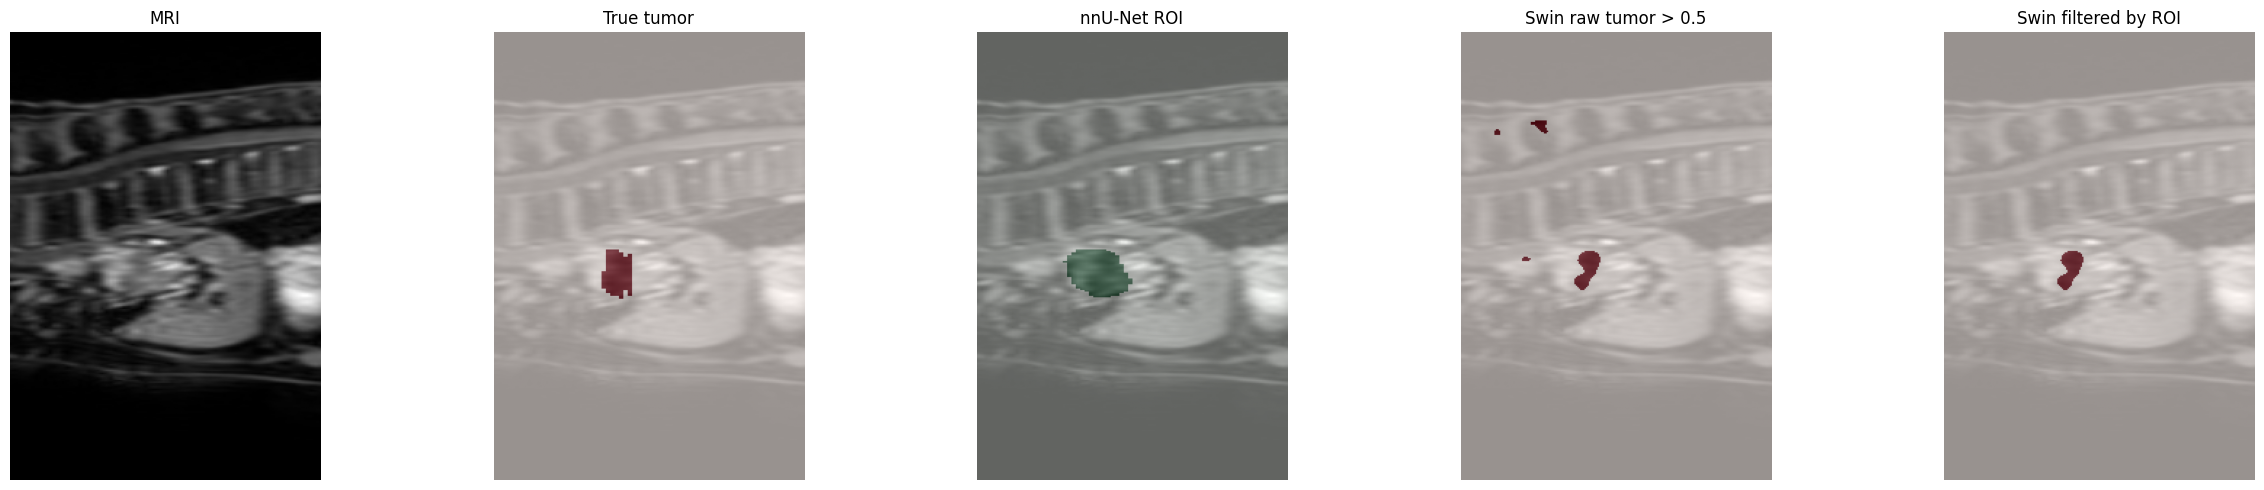

Case: 1
ROI Dice: 0.9502520271755583
Raw tumor Dice: 0.48243390077309106
Filtered tumor Dice: 0.7264662036968161
Raw voxels: 24792
Filtered voxels: 10880


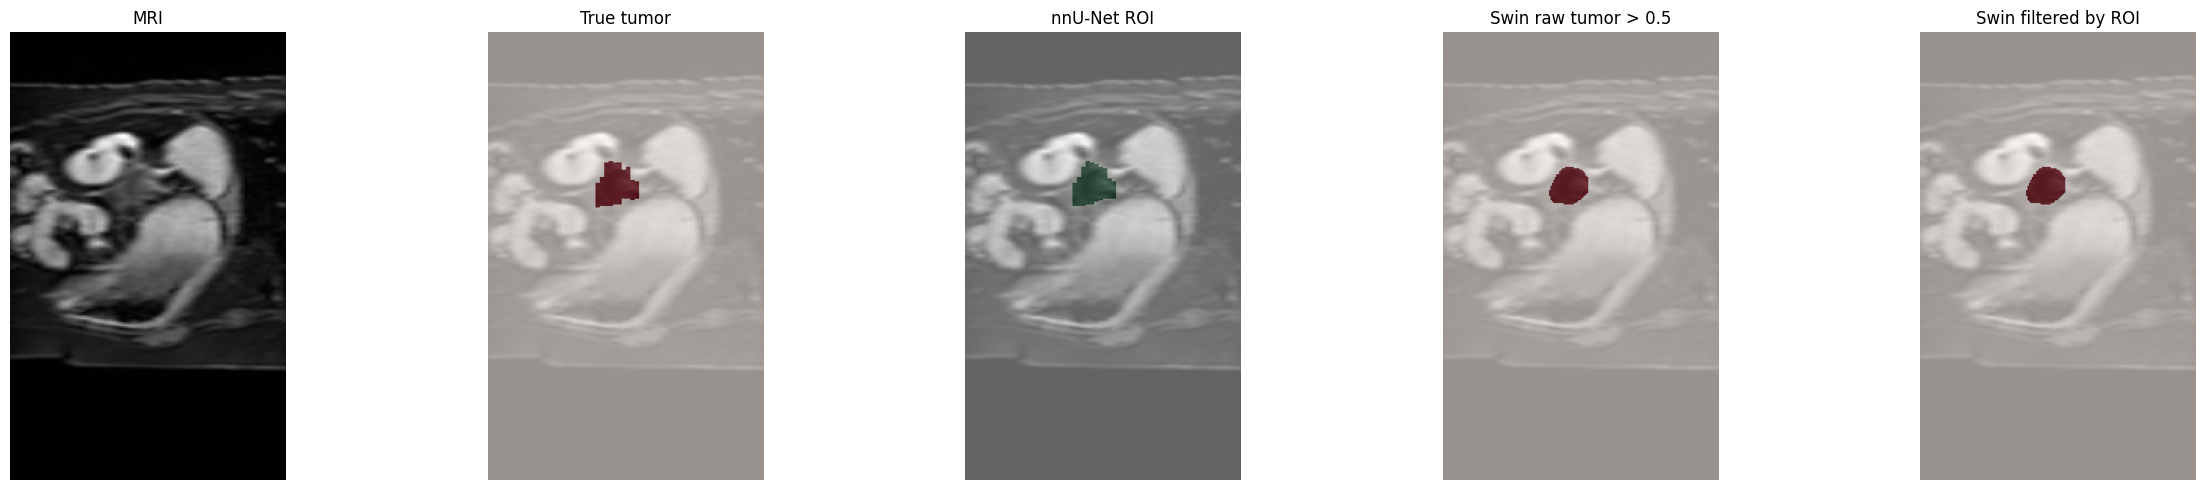

Case: 2
ROI Dice: 0.9464054675254253
Raw tumor Dice: 0.05769230771187713
Filtered tumor Dice: 0.47970989475397857
Raw voxels: 44441
Filtered voxels: 2080


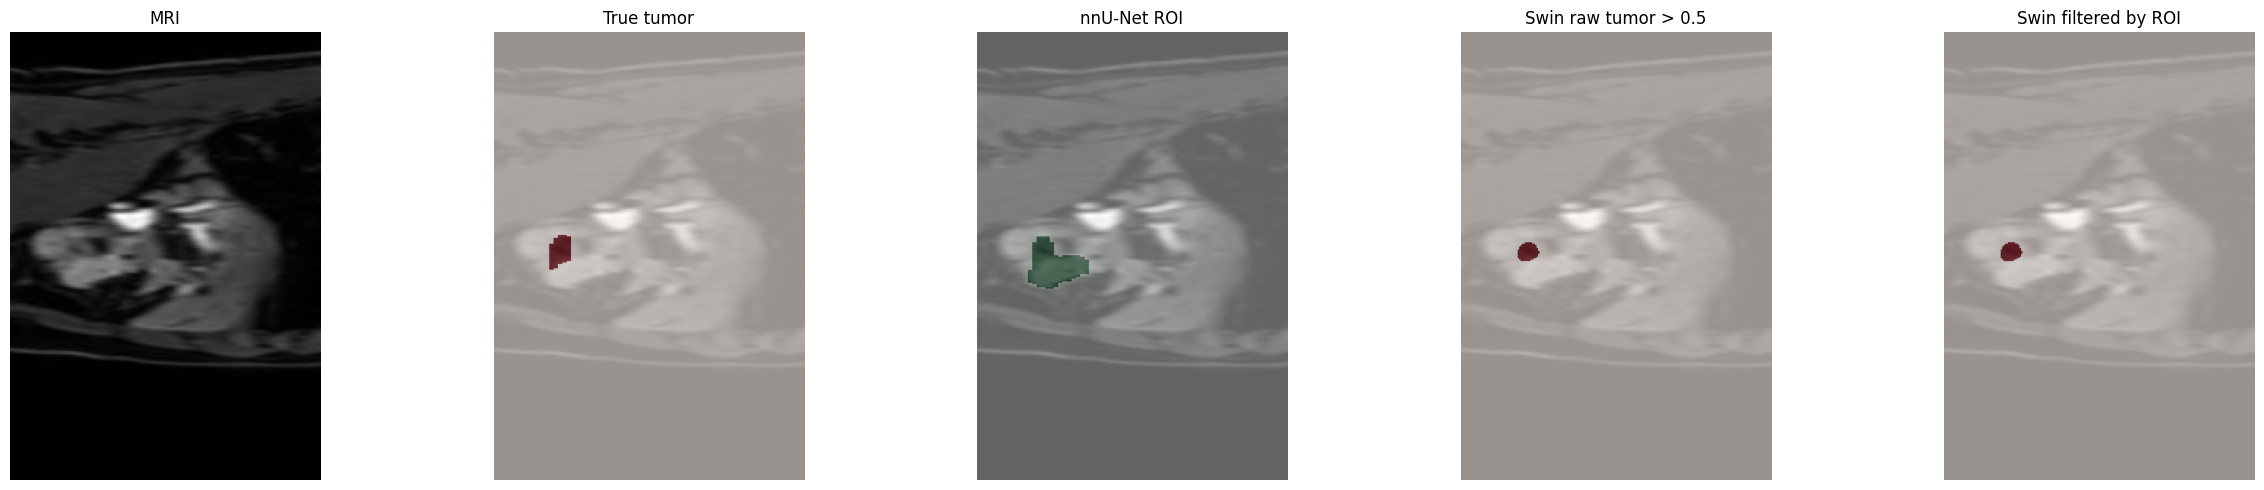

Case: 3
ROI Dice: 0.961533137487316
Raw tumor Dice: 0.5977304139158047
Filtered tumor Dice: 0.7643009952617361
Raw voxels: 30598
Filtered voxels: 18614


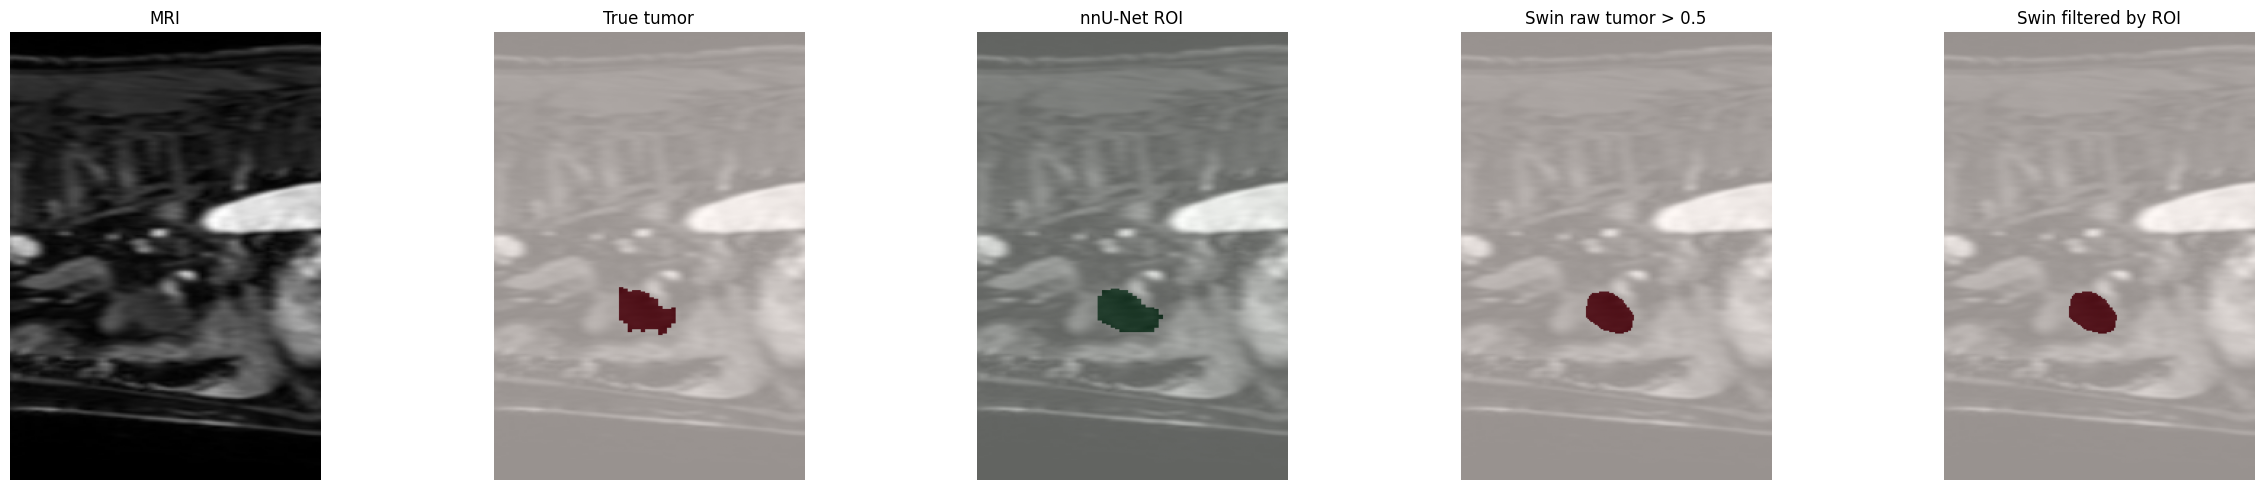

Case: 4
ROI Dice: 0.9542888804241306
Raw tumor Dice: 0.5736635305297695
Filtered tumor Dice: 0.8555913978572263
Raw voxels: 18438
Filtered voxels: 9297


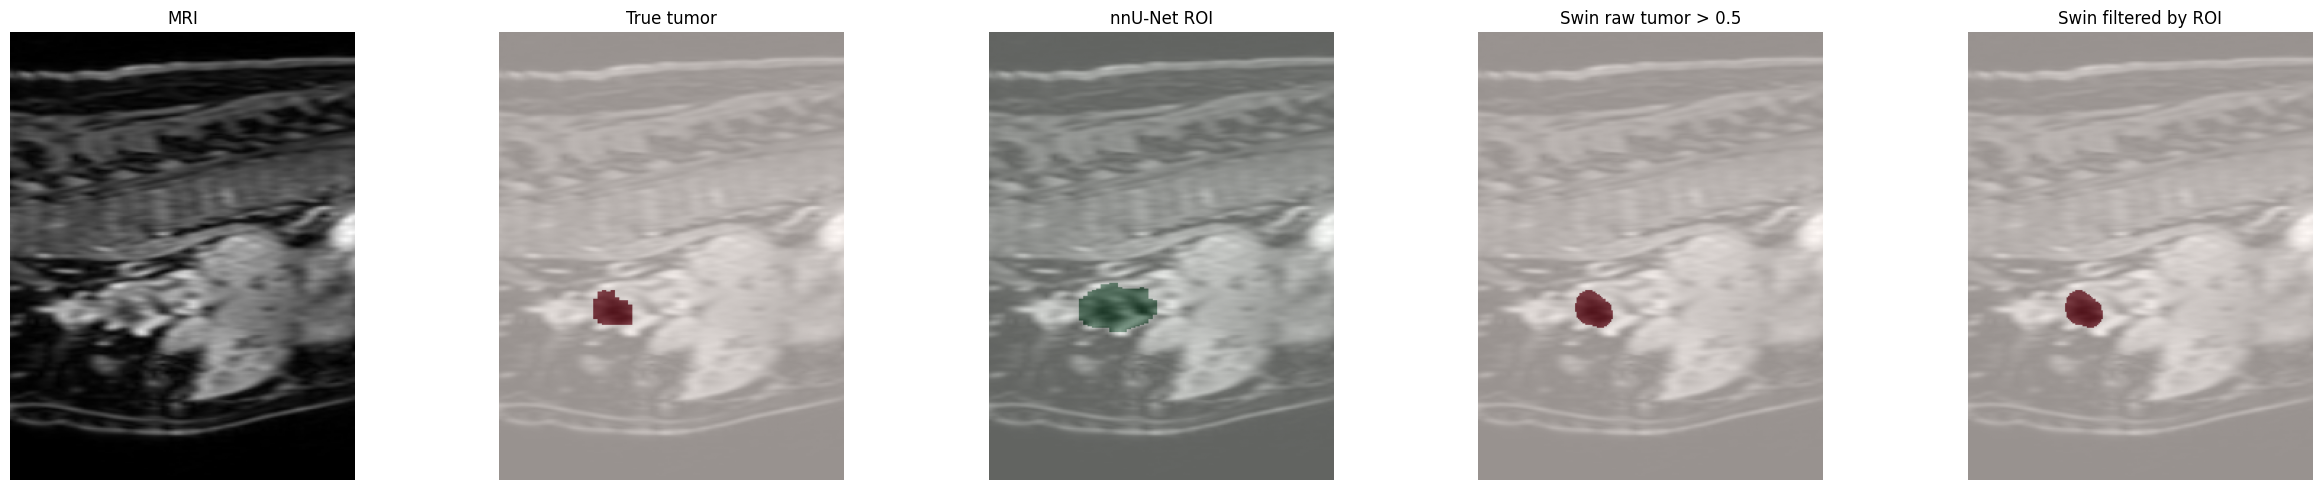

In [ ]:
def show_case(case_idx=0, thr=0.3, dil=0):
    batch = val_ds[case_idx]

    image = batch["image"].unsqueeze(0).to(device)
    img_np = image[0, 0].cpu().numpy()
    label = batch["label"].squeeze().cpu().numpy().astype(np.uint8)
    roi_pred = batch["roi_pred"].squeeze().cpu().numpy().astype(np.uint8)

    true_tumor = label == 1
    true_roi = label > 0

    with torch.no_grad():
        logits = sliding_window_inference(
            image,
            roi_size=(96, 96, 96),
            sw_batch_size=1,
            predictor=swin,
            overlap=0.5,
            mode="gaussian",
        )
        probs = torch.softmax(logits, dim=1)
        tumor_prob = probs[0, 1].cpu().numpy()

    roi_mask = keep_largest_component(roi_pred > 0)
    roi_dilated = binary_dilation(roi_mask, iterations=5)

    raw_tumor = tumor_prob > thr
    filtered_tumor = raw_tumor & roi_dilated

    if true_tumor.sum() > 0:
        z = int(np.argmax(true_tumor.sum(axis=(1, 2))))
    else:
        z = img_np.shape[0] // 2

    print("Case:", case_idx)
    print("ROI Dice:", dice_binary(roi_mask, true_roi))
    print("Raw tumor Dice:", dice_binary(raw_tumor, true_tumor))
    print("Filtered tumor Dice:", dice_binary(filtered_tumor, true_tumor))
    print("Raw voxels:", raw_tumor.sum())
    print("Filtered voxels:", filtered_tumor.sum())

    fig, ax = plt.subplots(1, 5, figsize=(25, 5))

    ax[0].imshow(img_np[z], cmap="gray")
    ax[0].set_title("MRI")
    ax[0].axis("off")

    ax[1].imshow(img_np[z], cmap="gray")
    ax[1].imshow(true_tumor[z], alpha=0.6, cmap="Reds")
    ax[1].set_title("True tumor")
    ax[1].axis("off")

    ax[2].imshow(img_np[z], cmap="gray")
    ax[2].imshow(roi_mask[z], alpha=0.4, cmap="Greens")
    ax[2].set_title("nnU-Net ROI")
    ax[2].axis("off")

    ax[3].imshow(img_np[z], cmap="gray")
    ax[3].imshow(raw_tumor[z], alpha=0.6, cmap="Reds")
    ax[3].set_title(f"Swin raw tumor > {thr}")
    ax[3].axis("off")

    ax[4].imshow(img_np[z], cmap="gray")
    ax[4].imshow(filtered_tumor[z], alpha=0.6, cmap="Reds")
    ax[4].set_title("Swin filtered by ROI")
    ax[4].axis("off")

    plt.tight_layout()
    plt.show()

for i in range(min(5, len(val_ds))):
    show_case(i, thr=0.5)